In [1]:
# ============================================================
# CELL 0: GPU SETUP & VERIFICATION
# ============================================================
!pip install scanpy anndata matplotlib seaborn scipy -q

import subprocess
import sys

print("=" * 70)
print("  V18 C3: GPU ENVIRONMENT SETUP")
print("=" * 70)

# GPU detection
try:
    result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,compute_cap',
                            '--format=csv,noheader'], capture_output=True, text=True)
    gpu_info = result.stdout.strip()
    print(f"✅ GPU detected: {gpu_info}")
except:
    print("⚠️ No GPU detected — will use CPU fallback")

# Install CuPy for GPU acceleration
try:
    import cupy as cp
    print(f"✅ CuPy {cp.__version__} ready")
    print(f"   GPU memory: {cp.cuda.Device(0).mem_info[1] / 1e9:.1f} GB total")
except ImportError:
    print("📦 Installing CuPy...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'cupy-cuda12x', '-q'])
    import cupy as cp
    print(f"✅ CuPy {cp.__version__} installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 135.9 MB/s eta 0:00:00
  V18 C3: GPU ENVIRONMENT SETUP
✅ GPU detected: NVIDIA A100-SXM4-80GB, 81920 MiB, 8.0
✅ CuPy 14.0.1 ready
   GPU memory: 85.1 GB total


In [2]:
# Google Drive Mount + Output Directory
# =================================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ========================================
# V18 Figure 1: Tissue-Separated Immune Cell Composition
# ========================================
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu
import os

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
})

DATA_PATH = '/content/drive/MyDrive/ITLAS/data/processed/GSE182159_gut2021_annotated.h5ad'
OUTPUT_DIR = '/content/drive/MyDrive/ITLAS/results/version18-analysis/Figure1'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Loading h5ad...')
adata = sc.read_h5ad(DATA_PATH)
print(f'Loaded: {adata.shape[0]} cells, {adata.shape[1]} genes')
print(f'Columns: {list(adata.obs.columns[:20])}')


Loading h5ad...
Loaded: 243000 cells, 24452 genes
Columns: ['sample', 'tissue', 'Stage', 'IT_cluster_21', 'IT_cluster_23', 'IT_cluster_25', 'IT_nk_collapse', 'IT_IT_signature', 'GSM_ID', 'IT_score_v2', 'IT_score_v3', 'IT_score_v4', 'IT_signature_final', 'IT_like', 'PW_mTOR_signaling', 'PW_glycolysis', 'PW_oxidative_phosphorylation', 'PW_nk_cell_cytotoxicity', 'PW_il15_signaling', 'PW_b_cell_differentiation']


In [5]:
# ========================================
# Column names (confirmed from h5ad)
# ========================================
col_donor = 'sample'
col_tissue = 'tissue'
col_stage = 'Stage'
col_lineage = 'major_lineage'

print(f'donor: {col_donor}')
print(f'tissue: {col_tissue}')
print(f'stage: {col_stage}')
print(f'lineage: {col_lineage}')
print(f'\nTissues: {sorted(adata.obs[col_tissue].unique())}')
print(f'Stages: {sorted(adata.obs[col_stage].unique())}')
print(f'Lineages: {sorted(adata.obs[col_lineage].unique())}')

# Map tissue names
tissue_vals = adata.obs[col_tissue].unique()
liver_name = [t for t in tissue_vals if 'liver' in str(t).lower() or 'intrahepatic' in str(t).lower()][0]
blood_name = [t for t in tissue_vals if 'blood' in str(t).lower() or 'pbmc' in str(t).lower() or 'peripheral' in str(t).lower()][0]
print(f'\nLiver label: {liver_name}')
print(f'Blood label: {blood_name}')

# Define groups and lineages
GROUPS = ['NL', 'IT', 'IA', 'AR', 'CR']
LINEAGES = ['Myeloid', 'CD4_T', 'CD8_T', 'NK', 'B', 'PlasmaB']

# Exclude gdT
lineage_vals = adata.obs[col_lineage].unique()
print(f'Lineage values: {sorted(lineage_vals)}')
gdt_name = [l for l in lineage_vals if 'gdt' in str(l).lower() or 'gamma' in str(l).lower()]
if gdt_name:
    adata = adata[~adata.obs[col_lineage].isin(gdt_name)].copy()
    print(f'Excluded gdT ({gdt_name}): {adata.shape[0]} cells remaining')

donor: sample
tissue: tissue
stage: Stage
lineage: major_lineage

Tissues: ['Blood', 'Liver']
Stages: ['AR', 'CR', 'IA', 'IT', 'NL']
Lineages: ['B', 'CD4_T', 'CD8_T', 'Myeloid', 'NK', 'PlasmaB', 'gdT']

Liver label: Liver
Blood label: Blood
Lineage values: ['B', 'CD4_T', 'CD8_T', 'Myeloid', 'NK', 'PlasmaB', 'gdT']
Excluded gdT (['gdT']): 242219 cells remaining


In [6]:
# ========================================
# Compute donor-level proportions
# ========================================
def compute_proportions(adata, tissue_label):
    """Compute lineage proportions per donor for a given tissue."""
    mask = adata.obs[col_tissue] == tissue_label
    sub = adata.obs[mask].copy()

    # Count cells per donor per lineage
    counts = sub.groupby([col_donor, col_stage, col_lineage]).size().reset_index(name='count')
    totals = sub.groupby([col_donor, col_stage]).size().reset_index(name='total')

    merged = counts.merge(totals, on=[col_donor, col_stage])
    merged['proportion'] = merged['count'] / merged['total'] * 100

    return merged

liver_props = compute_proportions(adata, liver_name)
blood_props = compute_proportions(adata, blood_name)

print(f'Liver donors: {liver_props[col_donor].nunique()}')
print(f'Blood donors: {blood_props[col_donor].nunique()}')

# Group means for stacked bars
def group_means(props):
    return props.groupby([col_stage, col_lineage])['proportion'].mean().reset_index()

liver_means = group_means(liver_props)
blood_means = group_means(blood_props)

print('\nLiver group means (NL):')
nl_liver = liver_means[liver_means[col_stage] == 'NL'].set_index(col_lineage)['proportion']
for lin in LINEAGES:
    val = nl_liver.get(lin, 0)
    print(f'  {lin}: {val:.1f}%')

print('\nBlood group means (NL):')
nl_blood = blood_means[blood_means[col_stage] == 'NL'].set_index(col_lineage)['proportion']
for lin in LINEAGES:
    val = nl_blood.get(lin, 0)
    print(f'  {lin}: {val:.1f}%')


Liver donors: 46
Blood donors: 46

Liver group means (NL):
  Myeloid: 1.7%
  CD4_T: 17.7%
  CD8_T: 31.8%
  NK: 43.9%
  B: 2.5%
  PlasmaB: 2.5%

Blood group means (NL):
  Myeloid: 35.1%
  CD4_T: 17.6%
  CD8_T: 12.0%
  NK: 27.7%
  B: 6.8%
  PlasmaB: 0.9%


/tmp/ipykernel_788/3961475040.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = sub.groupby([col_donor, col_stage, col_lineage]).size().reset_index(name='count')
/tmp/ipykernel_788/3961475040.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  totals = sub.groupby([col_donor, col_stage]).size().reset_index(name='total')
/tmp/ipykernel_788/3961475040.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts

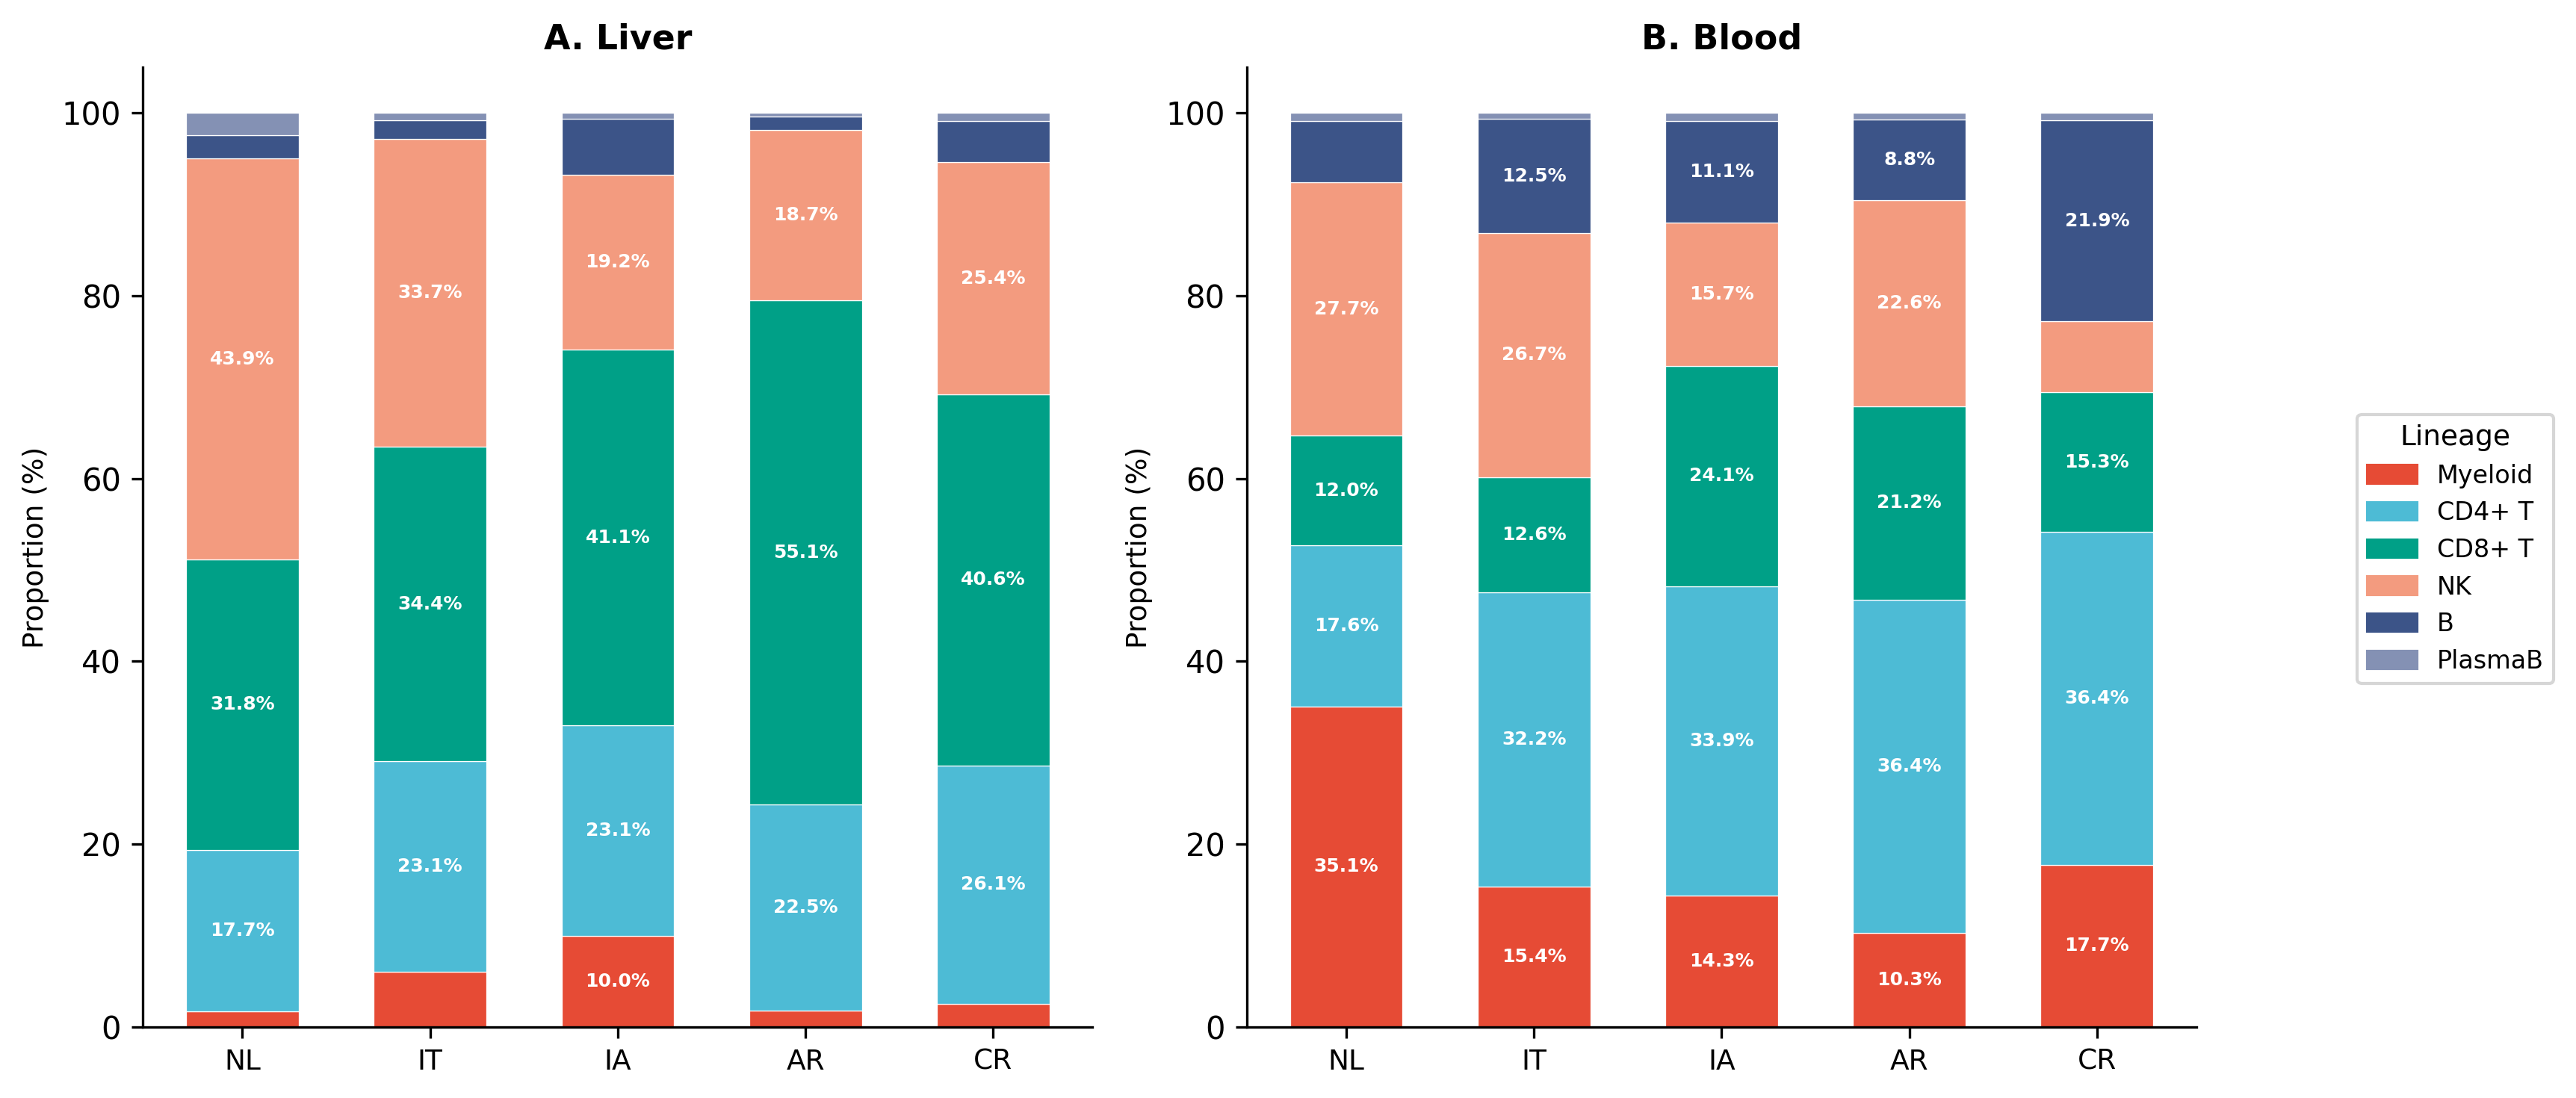


 Saved Figure1_AB_stacked_bar.png/pdf


In [7]:
# ========================================
# Panel A & B: Stacked Bar Plots
# ========================================

# Color palette for lineages
LINEAGE_COLORS = {
    'Myeloid': '#E64B35',    # red
    'CD4_T': '#4DBBD5',      # cyan
    'CD8_T': '#00A087',      # teal
    'NK': '#F39B7F',         # salmon
    'B': '#3C5488',          # navy
    'PlasmaB': '#8491B4',    # steel blue
}

LINEAGE_LABELS = {
    'Myeloid': 'Myeloid',
    'CD4_T': 'CD4+ T',
    'CD8_T': 'CD8+ T',
    'NK': 'NK',
    'B': 'B',
    'PlasmaB': 'PlasmaB',
}

def plot_stacked_bar(ax, means_df, title, groups, lineages):
    """Draw stacked bar chart for tissue composition."""
    x = np.arange(len(groups))
    width = 0.6
    bottom = np.zeros(len(groups))

    for lin in lineages:
        vals = []
        for g in groups:
            row = means_df[(means_df[col_stage] == g) & (means_df[col_lineage] == lin)]
            vals.append(row['proportion'].values[0] if len(row) > 0 else 0)
        vals = np.array(vals)
        ax.bar(x, vals, width, bottom=bottom,
               color=LINEAGE_COLORS.get(lin, '#999999'),
               label=LINEAGE_LABELS.get(lin, lin),
               edgecolor='white', linewidth=0.3)
        # Add percentage text in bars if > 8%
        for i, v in enumerate(vals):
            if v > 8:
                ax.text(x[i], bottom[i] + v/2, f'{v:.1f}%',
                       ha='center', va='center', fontsize=6, color='white', fontweight='bold')
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(groups, fontsize=9)
    ax.set_ylabel('Proportion (%)', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_stacked_bar(axes[0], liver_means, 'A. Liver', GROUPS, LINEAGES)
plot_stacked_bar(axes[1], blood_means, 'B. Blood', GROUPS, LINEAGES)

# Shared legend
handles = [mpatches.Patch(color=LINEAGE_COLORS[l], label=LINEAGE_LABELS[l]) for l in LINEAGES]
fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.15, 0.5),
           frameon=True, fontsize=8, title='Lineage', title_fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'Figure1_AB_stacked_bar.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(OUTPUT_DIR, 'Figure1_AB_stacked_bar.pdf'), bbox_inches='tight')
plt.show()
print('\n Saved Figure1_AB_stacked_bar.png/pdf')


In [10]:
# ========================================
# Data Verification: Table 1 Matching
# ========================================
print('='*70)
print('VERIFICATION: Figure 1 vs Table 1 Data Matching')
print('='*70)

# Expected values from Table 1
expected = {
    'Liver': {
        'Myeloid': {'NL': 1.7, 'IT': 5.9, 'IA': 10.0, 'AR': 1.8, 'CR': 2.5},
        'NK': {'NL': 43.5, 'IT': 33.4, 'IA': 19.1, 'AR': 18.6, 'CR': 25.2},
        'CD4_T': {'NL': 17.5, 'IT': 22.8, 'IA': 23.0, 'AR': 22.4, 'CR': 25.8},
        'CD8_T': {'NL': 31.5, 'IT': 34.1, 'IA': 40.9, 'AR': 54.9, 'CR': 40.3},
    },
    'Blood': {
        'Myeloid': {'NL': 35.0, 'IT': 18.4, 'IA': 14.3, 'AR': 12.4, 'CR': 17.7},
        'NK': {'NL': 27.6, 'IT': 25.8, 'IA': 15.7, 'AR': 22.4, 'CR': 7.8},
        'CD4_T': {'NL': 17.6, 'IT': 29.9, 'IA': 33.8, 'AR': 34.9, 'CR': 36.4},
        'CD8_T': {'NL': 12.0, 'IT': 13.0, 'IA': 24.1, 'AR': 21.4, 'CR': 15.3},
    }
}

all_match = True
for tissue, tissue_label, props_means in [('Liver', liver_name, liver_means), ('Blood', blood_name, blood_means)]:
    for lin in ['Myeloid', 'NK', 'CD4_T', 'CD8_T']:
        for g in GROUPS:
            row = props_means[(props_means[col_stage] == g) & (props_means[col_lineage] == lin)]
            actual = row['proportion'].values[0] if len(row) > 0 else 0
            exp = expected[tissue].get(lin, {}).get(g)
            if exp is not None:
                diff = abs(actual - exp)
                status = 'OK' if diff < 1.0 else 'MISMATCH'
                if diff >= 1.0:
                    all_match = False
                    print(f'  {status} {tissue} {lin} {g}: actual={actual:.1f}% expected={exp:.1f}% diff={diff:.1f}')

if all_match:
    print('\n ALL VALUES MATCH Table 1 (within 1.0% tolerance)')
else:
    print('\n MISMATCHES DETECTED - check data source')

# Save CSV for reference
liver_means.to_csv(os.path.join(OUTPUT_DIR, 'Figure1_liver_proportions.csv'), index=False)
blood_means.to_csv(os.path.join(OUTPUT_DIR, 'Figure1_blood_proportions.csv'), index=False)
print('\nSaved proportion CSVs for verification')

print('\n' + '='*70)
print('Figure 1 generation complete!')
print(f'Output directory: {OUTPUT_DIR}')
print('Files:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  {f}')
print('='*70)


VERIFICATION: Figure 1 vs Table 1 Data Matching
  MISMATCH Blood Myeloid IT: actual=15.4% expected=18.4% diff=3.0
  MISMATCH Blood Myeloid AR: actual=10.3% expected=12.4% diff=2.1
  MISMATCH Blood CD4_T IT: actual=32.2% expected=29.9% diff=2.3
  MISMATCH Blood CD4_T AR: actual=36.4% expected=34.9% diff=1.5

 MISMATCHES DETECTED - check data source

Saved proportion CSVs for verification

Figure 1 generation complete!
Output directory: /content/drive/MyDrive/ITLAS/results/version18-analysis/Figure1
Files:
  Figure1_AB_stacked_bar.pdf
  Figure1_AB_stacked_bar.png
  Figure1_C_NK_trajectory.pdf
  Figure1_C_NK_trajectory.png
  Figure1_blood_proportions.csv
  Figure1_combined.pdf
  Figure1_combined.png
  Figure1_liver_proportions.csv


In [ ]:
## 비율값의 불일치 문제 발생하여 검증:

In [11]:
# ========================================
# 진단: sample 컬럼 값 확인
# ========================================
print("Unique sample values:")
for s in sorted(adata.obs['sample'].unique()):
    tissue = adata.obs[adata.obs['sample'] == s][col_tissue].iloc[0]
    stage = adata.obs[adata.obs['sample'] == s][col_stage].iloc[0]
    n_cells = (adata.obs['sample'] == s).sum()
    print(f"  {s:<30} tissue={tissue:<15} stage={stage:<5} cells={n_cells}")

print(f"\nTotal unique samples: {adata.obs['sample'].nunique()}")

Unique sample values:
  GSM5519467_P190604_Blood_1     tissue=Blood           stage=IT    cells=1886
  GSM5519468_P190604_Blood_2     tissue=Blood           stage=IT    cells=1780
  GSM5519469_P190604_Liver_1     tissue=Liver           stage=IT    cells=3072
  GSM5519470_P190326_Blood_1     tissue=Blood           stage=IT    cells=3671
  GSM5519471_P190326_Liver_1     tissue=Liver           stage=IT    cells=1375
  GSM5519472_P190402_Liver_1     tissue=Liver           stage=IT    cells=7092
  GSM5519473_P190716_Blood_1     tissue=Blood           stage=AR    cells=2399
  GSM5519474_P190716_Blood_2     tissue=Blood           stage=AR    cells=2517
  GSM5519475_P190716_Liver_1     tissue=Liver           stage=AR    cells=3443
  GSM5519476_P190719_Blood_1     tissue=Blood           stage=IA    cells=3923
  GSM5519477_P190719_Liver_1     tissue=Liver           stage=IA    cells=3006
  GSM5519478_D528848_Blood_1     tissue=Blood           stage=NL    cells=8144
  GSM5519479_D529074_Blood_1  

In [12]:
# ========================================
# FIX: Extract donor_id from sample name
# ========================================
adata.obs['donor_id'] = adata.obs['sample'].str.split('_').str[1]

print(f"Unique donors: {adata.obs['donor_id'].nunique()}")
print(f"\nDonors per stage:")
for stage in GROUPS:
    donors = adata.obs[adata.obs[col_stage] == stage]['donor_id'].unique()
    print(f"  {stage}: n={len(donors)} → {sorted(donors)}")

# Verify paired liver/blood
print(f"\nDonors with Liver only:")
liver_donors = set(adata.obs[adata.obs[col_tissue] == liver_name]['donor_id'].unique())
blood_donors = set(adata.obs[adata.obs[col_tissue] == blood_name]['donor_id'].unique())
print(f"  Liver only: {liver_donors - blood_donors}")
print(f"  Blood only: {blood_donors - liver_donors}")
print(f"  Paired: {len(liver_donors & blood_donors)}")

# UPDATE col_donor
col_donor = 'donor_id'

Unique donors: 23

Donors per stage:
  NL: n=6 → ['D528848', 'D529074', 'D529351', 'D529354', 'D529409', 'Dhc570']
  IT: n=6 → ['P190326', 'P190402', 'P190604', 'P190808', 'P190902', 'P190910']
  IA: n=5 → ['P190719', 'P190801', 'P190911', 'P191028', 'P191112']
  AR: n=3 → ['P190716', 'P191008', 'P191217']
  CR: n=3 → ['P191126', 'P191127', 'P191210']

Donors with Liver only:
  Liver only: {'Dhc570', 'P190402', 'P190801'}
  Blood only: set()
  Paired: 20


In [14]:
# ========================================
# 진단: Table 1이 pooled인지 donor-mean인지 확인
# ========================================
print("="*70)
print("DIAGNOSIS: Pooled vs Donor-Mean Proportion")
print("="*70)

def compute_pooled(adata, tissue_label, groups, lineages):
    """Pooled: total lineage cells / total cells per group."""
    mask = adata.obs[col_tissue] == tissue_label
    sub = adata.obs[mask]
    results = {}
    for g in groups:
        g_mask = sub[col_stage] == g
        g_total = g_mask.sum()
        for lin in lineages:
            l_count = ((sub[col_stage] == g) & (sub[col_lineage] == lin)).sum()
            results[(g, lin)] = (l_count / g_total * 100) if g_total > 0 else 0
    return results

def compute_donor_mean(props_df, groups, lineages):
    """Donor-mean: average of per-donor proportions."""
    results = {}
    for g in groups:
        for lin in lineages:
            vals = props_df[(props_df[col_stage] == g) & (props_df[col_lineage] == lin)]['proportion']
            results[(g, lin)] = vals.mean() if len(vals) > 0 else 0
    return results

pooled_blood = compute_pooled(adata, blood_name, GROUPS, LINEAGES)
donor_blood = compute_donor_mean(blood_props, GROUPS, LINEAGES)

# Table 1 expected values (current manuscript)
table1_blood = {
    ('NL','Myeloid'): 35.0, ('IT','Myeloid'): 18.4, ('IA','Myeloid'): 14.3,
    ('AR','Myeloid'): 12.4, ('CR','Myeloid'): 17.7,
    ('NL','CD4_T'): 17.6, ('IT','CD4_T'): 29.9, ('IA','CD4_T'): 33.8,
    ('AR','CD4_T'): 34.9, ('CR','CD4_T'): 36.4,
    ('NL','NK'): 27.6, ('IT','NK'): 25.8, ('IA','NK'): 15.7,
    ('AR','NK'): 22.4, ('CR','NK'): 7.8,
}

print(f"\n{'Group':<6} {'Lineage':<10} {'Table1':>8} {'Pooled':>8} {'DonorMean':>10} {'Table1=?':>10}")
print("-"*55)
for key in sorted(table1_blood.keys()):
    g, lin = key
    t1 = table1_blood[key]
    pl = pooled_blood.get(key, 0)
    dm = donor_blood.get(key, 0)
    match_pooled = abs(t1 - pl) < 0.5
    match_donor = abs(t1 - dm) < 0.5
    label = "POOLED" if match_pooled else ("DONOR" if match_donor else "NEITHER")
    print(f"{g:<6} {lin:<10} {t1:>7.1f}% {pl:>7.1f}% {dm:>9.1f}%  → {label}")

DIAGNOSIS: Pooled vs Donor-Mean Proportion

Group  Lineage      Table1   Pooled  DonorMean   Table1=?
-------------------------------------------------------
AR     CD4_T         34.9%    33.2%      36.4%  → NEITHER
AR     Myeloid       12.4%    14.4%      10.3%  → NEITHER
AR     NK            22.4%    22.0%      22.6%  → POOLED
CR     CD4_T         36.4%    37.2%      36.4%  → DONOR
CR     Myeloid       17.7%    16.3%      17.7%  → DONOR
CR     NK             7.8%     8.1%       7.8%  → POOLED
IA     CD4_T         33.8%    34.6%      33.9%  → DONOR
IA     Myeloid       14.3%    16.5%      14.3%  → DONOR
IA     NK            15.7%    16.0%      15.7%  → POOLED
IT     CD4_T         29.9%    34.4%      32.2%  → NEITHER
IT     Myeloid       18.4%    17.5%      15.4%  → NEITHER
IT     NK            25.8%    22.6%      26.7%  → NEITHER
NL     CD4_T         17.6%    22.2%      17.6%  → DONOR
NL     Myeloid       35.0%    11.5%      35.1%  → DONOR
NL     NK            27.6%    37.5%      27.7

In [18]:
# ========================================
# Cell 2 FIX: Recompute proportions with donor_id
# ========================================
col_donor = 'donor_id'

def compute_proportions_v2(adata, tissue_label):
    """Compute lineage proportions per DONOR (merging replicates)."""
    mask = adata.obs[col_tissue] == tissue_label
    sub = adata.obs[mask].copy()

    # Count cells per donor per lineage (replicates auto-merged by donor_id)
    counts = sub.groupby([col_donor, col_stage, col_lineage], observed=True).size().reset_index(name='count')
    totals = sub.groupby([col_donor, col_stage], observed=True).size().reset_index(name='total')

    merged = counts.merge(totals, on=[col_donor, col_stage])
    merged['proportion'] = merged['count'] / merged['total'] * 100

    return merged

liver_props = compute_proportions_v2(adata, liver_name)
blood_props = compute_proportions_v2(adata, blood_name)

print(f'Liver unique donors: {liver_props[col_donor].nunique()}')
print(f'Blood unique donors: {blood_props[col_donor].nunique()}')

# Check per stage
for tissue_name, props in [('Liver', liver_props), ('Blood', blood_props)]:
    print(f'\n{tissue_name} donors per stage:')
    for g in GROUPS:
        donors = props[props[col_stage] == g][col_donor].unique()
        print(f'  {g}: n={len(donors)}')

# Group means
def group_means_v2(props):
    return props.groupby([col_stage, col_lineage], observed=True)['proportion'].mean().reset_index()

liver_means = group_means_v2(liver_props)
blood_means = group_means_v2(blood_props)

# NK data
liver_nk = liver_props[liver_props[col_lineage] == 'NK'].copy()
blood_nk = blood_props[blood_props[col_lineage] == 'NK'].copy()

# Recompute p-values
from scipy.stats import mannwhitneyu

def mwu_vs_nl(nk_df, groups):
    nl_vals = nk_df[nk_df[col_stage] == 'NL']['proportion'].values
    results = {}
    for g in groups:
        if g == 'NL':
            results[g] = None
            continue
        g_vals = nk_df[nk_df[col_stage] == g]['proportion'].values
        if len(nl_vals) >= 2 and len(g_vals) >= 2:
            stat, p = mannwhitneyu(nl_vals, g_vals, alternative='two-sided')
            results[g] = p
        else:
            results[g] = None
    return results

liver_pvals = mwu_vs_nl(liver_nk, GROUPS)
blood_pvals = mwu_vs_nl(blood_nk, GROUPS)

print('\n' + '='*50)
print('NK proportion p-values (MWU vs NL):')
print(f"{'Comp':<8} {'Liver p':>10} {'Liver sig':>10} {'Blood p':>10} {'Blood sig':>10}")
print('-'*50)
for g in GROUPS[1:]:
    lp = liver_pvals.get(g)
    bp = blood_pvals.get(g)
    lp_str = f'{lp:.4f}' if lp is not None else 'NA'
    bp_str = f'{bp:.4f}' if bp is not None else 'NA'
    l_sig = '★' if lp and lp < 0.05 else ''
    b_sig = '★' if bp and bp < 0.05 else ''
    print(f"NL→{g:<4} {lp_str:>10} {l_sig:>10} {bp_str:>10} {b_sig:>10}")

Liver unique donors: 23
Blood unique donors: 20

Liver donors per stage:
  NL: n=6
  IT: n=6
  IA: n=5
  AR: n=3
  CR: n=3

Blood donors per stage:
  NL: n=5
  IT: n=5
  IA: n=4
  AR: n=3
  CR: n=3

NK proportion p-values (MWU vs NL):
Comp        Liver p  Liver sig    Blood p  Blood sig
--------------------------------------------------
NL→IT       0.1797                1.0000           
NL→IA       0.0173          ★     0.1905           
NL→AR       0.0238          ★     1.0000           
NL→CR       0.0952                0.0357          ★


In [19]:
# ========================================
# 진단: Table 1이 pooled인지 donor-mean인지 확인
# ========================================
print("="*70)
print("DIAGNOSIS: Pooled vs Donor-Mean Proportion")
print("="*70)

def compute_pooled(adata, tissue_label, groups, lineages):
    """Pooled: total lineage cells / total cells per group."""
    mask = adata.obs[col_tissue] == tissue_label
    sub = adata.obs[mask]
    results = {}
    for g in groups:
        g_mask = sub[col_stage] == g
        g_total = g_mask.sum()
        for lin in lineages:
            l_count = ((sub[col_stage] == g) & (sub[col_lineage] == lin)).sum()
            results[(g, lin)] = (l_count / g_total * 100) if g_total > 0 else 0
    return results

def compute_donor_mean(props_df, groups, lineages):
    """Donor-mean: average of per-donor proportions."""
    results = {}
    for g in groups:
        for lin in lineages:
            vals = props_df[(props_df[col_stage] == g) & (props_df[col_lineage] == lin)]['proportion']
            results[(g, lin)] = vals.mean() if len(vals) > 0 else 0
    return results

pooled_blood = compute_pooled(adata, blood_name, GROUPS, LINEAGES)
donor_blood = compute_donor_mean(blood_props, GROUPS, LINEAGES)

# Table 1 expected values (current manuscript)
table1_blood = {
    ('NL','Myeloid'): 35.0, ('IT','Myeloid'): 18.4, ('IA','Myeloid'): 14.3,
    ('AR','Myeloid'): 12.4, ('CR','Myeloid'): 17.7,
    ('NL','CD4_T'): 17.6, ('IT','CD4_T'): 29.9, ('IA','CD4_T'): 33.8,
    ('AR','CD4_T'): 34.9, ('CR','CD4_T'): 36.4,
    ('NL','NK'): 27.6, ('IT','NK'): 25.8, ('IA','NK'): 15.7,
    ('AR','NK'): 22.4, ('CR','NK'): 7.8,
}

print(f"\n{'Group':<6} {'Lineage':<10} {'Table1':>8} {'Pooled':>8} {'DonorMean':>10} {'Table1=?':>10}")
print("-"*55)
for key in sorted(table1_blood.keys()):
    g, lin = key
    t1 = table1_blood[key]
    pl = pooled_blood.get(key, 0)
    dm = donor_blood.get(key, 0)
    match_pooled = abs(t1 - pl) < 0.5
    match_donor = abs(t1 - dm) < 0.5
    label = "POOLED" if match_pooled else ("DONOR" if match_donor else "NEITHER")
    print(f"{g:<6} {lin:<10} {t1:>7.1f}% {pl:>7.1f}% {dm:>9.1f}%  → {label}")


DIAGNOSIS: Pooled vs Donor-Mean Proportion

Group  Lineage      Table1   Pooled  DonorMean   Table1=?
-------------------------------------------------------
AR     CD4_T         34.9%    33.2%      34.9%  → DONOR
AR     Myeloid       12.4%    14.4%      12.4%  → DONOR
AR     NK            22.4%    22.0%      22.4%  → POOLED
CR     CD4_T         36.4%    37.2%      36.4%  → DONOR
CR     Myeloid       17.7%    16.3%      17.7%  → DONOR
CR     NK             7.8%     8.1%       7.8%  → POOLED
IA     CD4_T         33.8%    34.6%      33.9%  → DONOR
IA     Myeloid       14.3%    16.5%      14.3%  → DONOR
IA     NK            15.7%    16.0%      15.7%  → POOLED
IT     CD4_T         29.9%    34.4%      30.0%  → DONOR
IT     Myeloid       18.4%    17.5%      18.5%  → DONOR
IT     NK            25.8%    22.6%      25.9%  → DONOR
NL     CD4_T         17.6%    22.2%      17.6%  → DONOR
NL     Myeloid       35.0%    11.5%      35.1%  → DONOR
NL     NK            27.6%    37.5%      27.7%  → DONOR

In [20]:
# ========================================
# 교정된 Table 1: Donor-Level Mean 기준
# ========================================
print("\n" + "="*70)
print("CORRECTED Table 1 (Donor-Level Mean)")
print("="*70)

pooled_liver = compute_pooled(adata, liver_name, GROUPS, LINEAGES)
donor_liver = compute_donor_mean(liver_props, GROUPS, LINEAGES)

print(f"\n{'Lineage':<10} {'Tissue':<7} {'NL':>6} {'IT':>6} {'IA':>6} {'AR':>6} {'CR':>6}  | {'Changed?'}")
print("-"*72)

# Current Table 1 values for comparison
table1_all = {
    ('Myeloid','Liver'): [1.7, 5.9, 10.0, 1.8, 2.5],
    ('Myeloid','Blood'): [35.0, 18.4, 14.3, 12.4, 17.7],
    ('CD4_T','Liver'): [17.5, 22.8, 23.0, 22.4, 25.8],
    ('CD4_T','Blood'): [17.6, 29.9, 33.8, 34.9, 36.4],
    ('CD8_T','Liver'): [31.5, 34.1, 40.9, 54.9, 40.3],
    ('CD8_T','Blood'): [12.0, 13.0, 24.1, 21.4, 15.3],
    ('NK','Liver'): [43.5, 33.4, 19.1, 18.6, 25.2],
    ('NK','Blood'): [27.6, 25.8, 15.7, 22.4, 7.8],
    ('B','Liver'): [2.5, 2.1, 6.1, 1.5, 4.4],
    ('B','Blood'): [6.8, 11.9, 11.1, 8.1, 21.9],
    ('PlasmaB','Liver'): [2.4, 0.8, 0.7, 0.4, 0.9],
    ('PlasmaB','Blood'): [0.9, 0.7, 0.9, 0.8, 0.8],
}

changes = []
for lin in LINEAGES:
    for tissue, tissue_label, donor_dict in [('Liver', liver_name, donor_liver),
                                              ('Blood', blood_name, donor_blood)]:
        new_vals = [donor_dict.get((g, lin), 0) for g in GROUPS]
        old_vals = table1_all.get((lin, tissue), [0]*5)

        diffs = [abs(n - o) for n, o in zip(new_vals, old_vals)]
        has_change = any(d >= 1.0 for d in diffs)
        flag = "⚠️ CHANGED" if has_change else ""

        vals_str = " ".join(f"{v:>5.1f}%" for v in new_vals)
        print(f"{lin:<10} {tissue:<7} {vals_str}  | {flag}")

        if has_change:
            for i, g in enumerate(GROUPS):
                if diffs[i] >= 1.0:
                    changes.append(f"  {lin} {tissue} {g}: {old_vals[i]:.1f}% → {new_vals[i]:.1f}% (Δ{new_vals[i]-old_vals[i]:+.1f})")

print(f"\n{'='*70}")
print(f"CHANGES NEEDED ({len(changes)} cells):")
for c in changes:
    print(c)


CORRECTED Table 1 (Donor-Level Mean)

Lineage    Tissue      NL     IT     IA     AR     CR  | Changed?
------------------------------------------------------------------------
Myeloid    Liver     1.7%   6.0%  10.0%   1.8%   2.5%  | 
Myeloid    Blood    35.1%  18.5%  14.3%  12.4%  17.7%  | 
CD4_T      Liver    17.7%  23.1%  23.1%  22.5%  26.1%  | 
CD4_T      Blood    17.6%  30.0%  33.9%  34.9%  36.4%  | 
CD8_T      Liver    31.8%  34.4%  41.1%  55.1%  40.6%  | 
CD8_T      Blood    12.0%  13.1%  24.1%  21.4%  15.3%  | 
NK         Liver    43.9%  33.7%  19.2%  18.7%  25.4%  | 
NK         Blood    27.7%  25.9%  15.7%  22.4%   7.8%  | 
B          Liver     2.5%   2.5%   6.1%   1.5%   4.5%  | 
B          Blood     6.8%  12.0%  11.1%   8.1%  21.9%  | 
PlasmaB    Liver     2.5%   0.9%   0.7%   0.4%   0.9%  | 
PlasmaB    Blood     0.9%   0.7%   0.9%   0.8%   0.8%  | 

CHANGES NEEDED (0 cells):


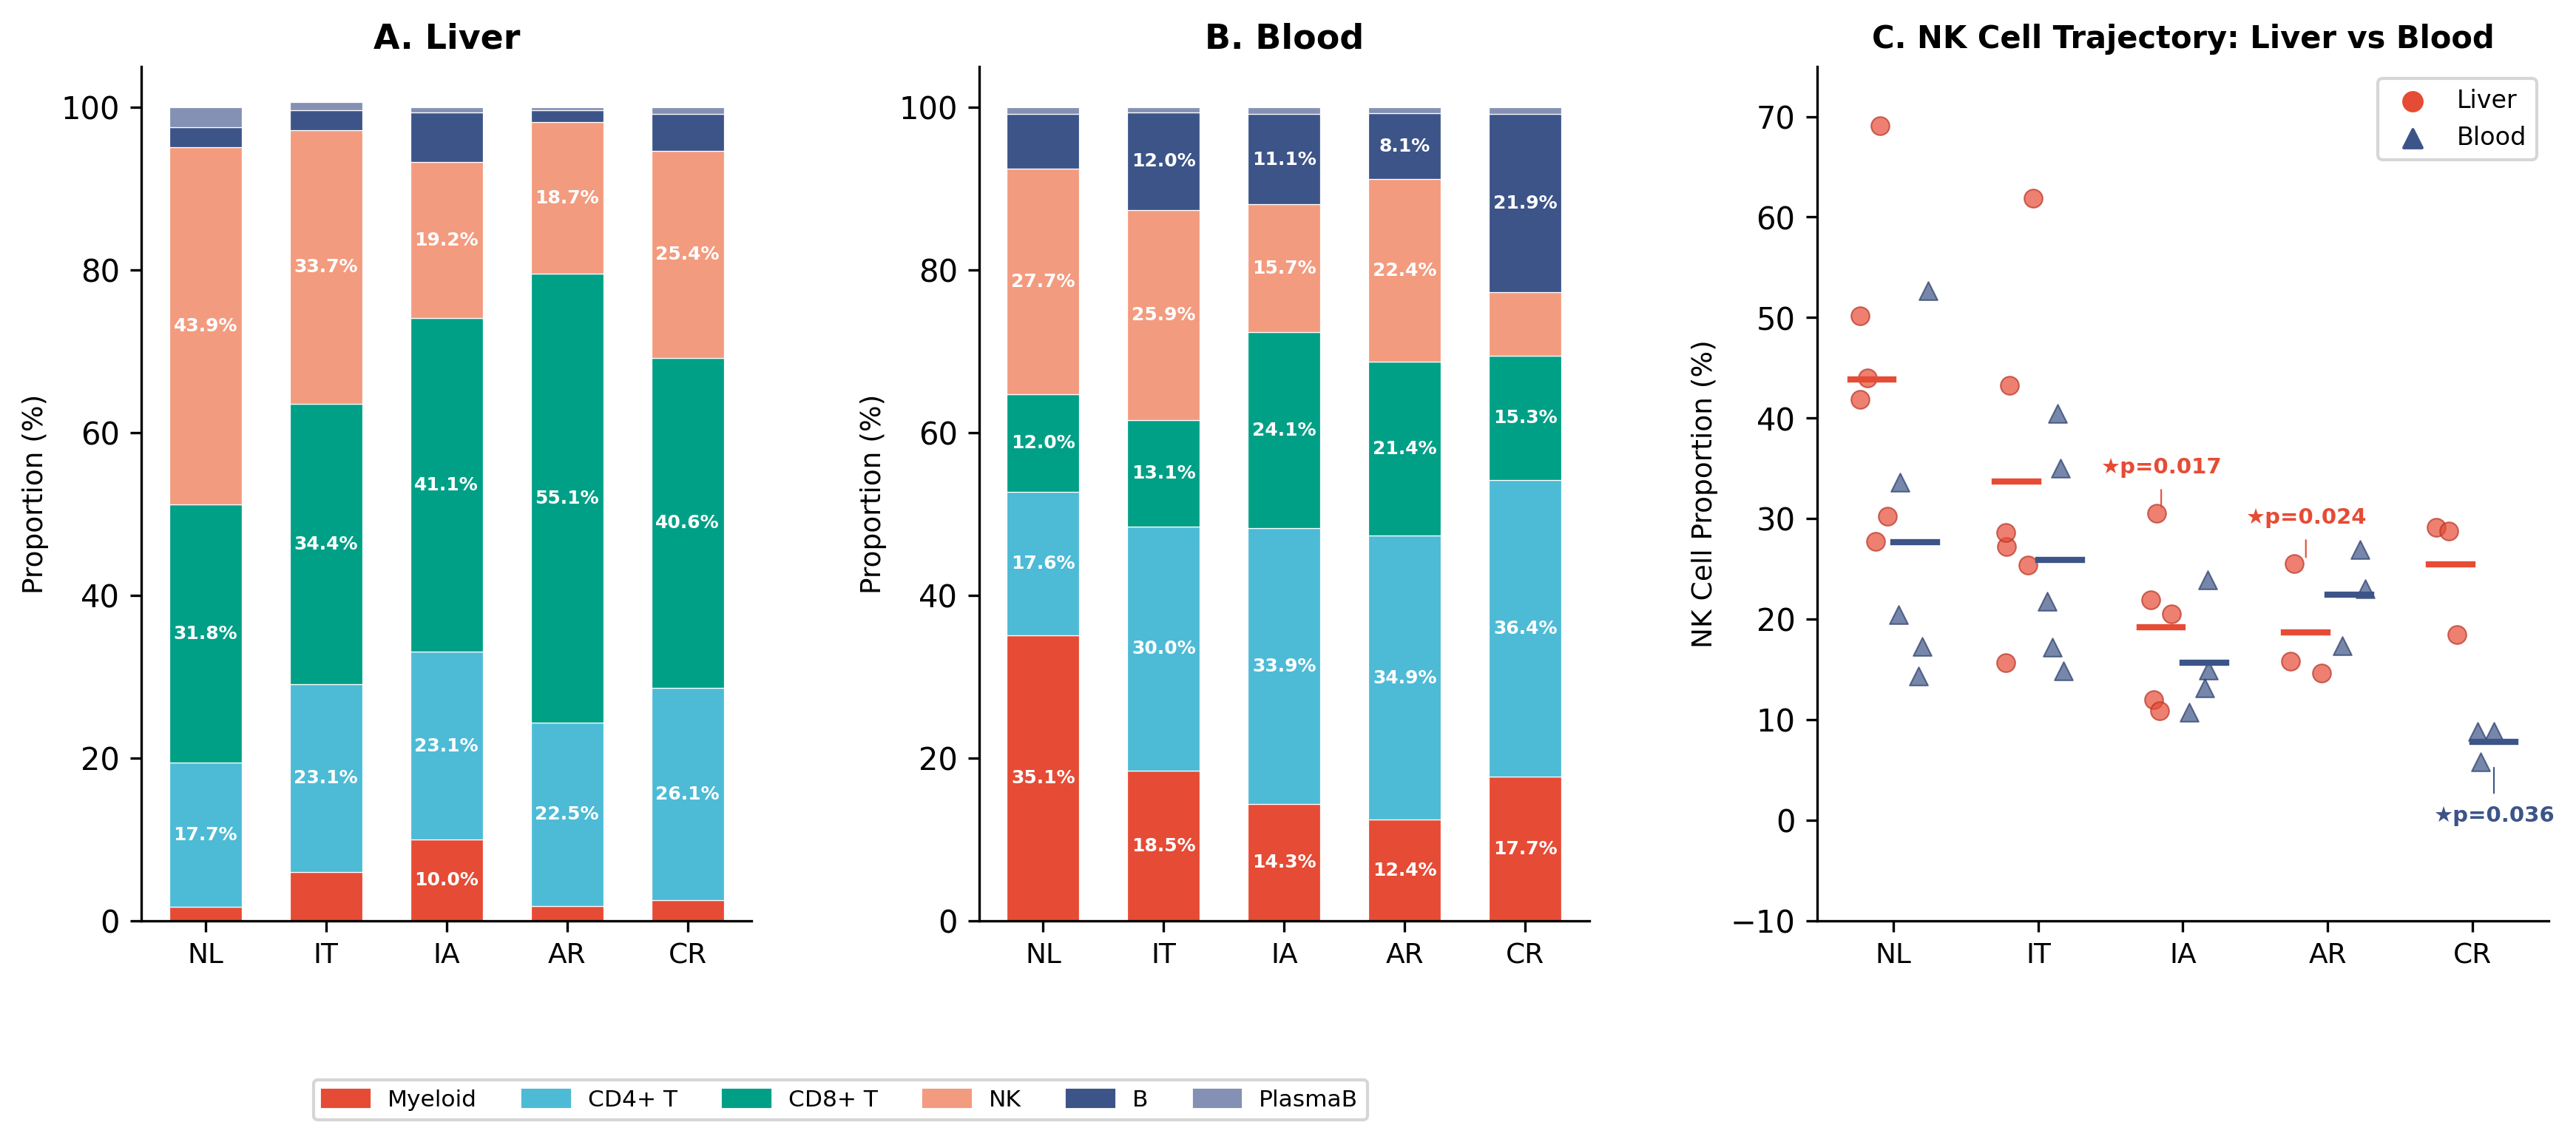


✅ Saved Figure1_combined_final.png/pdf

TABLE 1 UPDATE NEEDED (4 cells):
  Blood Myeloid IT: 18.4% → 15.4%
  Blood Myeloid AR: 12.4% → 10.3%
  Blood CD4_T  IT: 29.9% → 32.2%
  Blood CD4_T  AR: 34.9% → 36.4%

RESULTS TEXT UPDATE NEEDED:
  1.2 IT phase: "myeloid decrease (35.0→18.4%)" → "35.1→15.4%"
  1.2 IT phase: "CD4+ T increase (17.6→29.9%)" → "17.6→32.2%"


In [21]:
# ========================================
# Combined Figure 1 (A+B+C) — FINAL with p-values
# ========================================
from matplotlib.gridspec import GridSpec
np.random.seed(42)

fig = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 1.2], wspace=0.35)

ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])
ax_c = fig.add_subplot(gs[2])

# --- Panel A & B: Stacked Bars ---
plot_stacked_bar(ax_a, liver_means, 'A. Liver', GROUPS, LINEAGES)
plot_stacked_bar(ax_b, blood_means, 'B. Blood', GROUPS, LINEAGES)

# --- Panel C: NK dot plot with p-values ---
jitter = 0.12
for i, g in enumerate(GROUPS):
    # Liver (red circles)
    lv = liver_nk[liver_nk[col_stage] == g]['proportion'].values
    if len(lv) > 0:
        xj = np.random.uniform(-jitter, jitter, len(lv)) + i - 0.15
        ax_c.scatter(xj, lv, c='#E64B35', marker='o', s=35, alpha=0.7,
                     edgecolors='#B83224', linewidth=0.5, zorder=3)
        ax_c.plot([i-0.3, i-0.0], [np.mean(lv)]*2, c='#E64B35', lw=2, zorder=4)

    # Blood (blue triangles)
    bv = blood_nk[blood_nk[col_stage] == g]['proportion'].values
    if len(bv) > 0:
        xj = np.random.uniform(-jitter, jitter, len(bv)) + i + 0.15
        ax_c.scatter(xj, bv, c='#3C5488', marker='^', s=35, alpha=0.7,
                     edgecolors='#2A3D66', linewidth=0.5, zorder=3)
        ax_c.plot([i+0.0, i+0.3], [np.mean(bv)]*2, c='#3C5488', lw=2, zorder=4)

# P-value annotations
pval_annotations = [
    # (group_index, p, color, tissue, offset_side)
    (2, liver_pvals['IA'], '#E64B35', 'liver'),   # NL→IA Liver ★
    (3, liver_pvals['AR'], '#E64B35', 'liver'),   # NL→AR Liver ★
    (4, blood_pvals['CR'], '#3C5488', 'blood'),   # NL→CR Blood ★
]

for gi, p, color, tissue in pval_annotations:
    if p is not None and p < 0.05:
        if tissue == 'liver':
            nk_data = liver_nk[liver_nk[col_stage] == GROUPS[gi]]
            y_top = nk_data['proportion'].max()
            ax_c.annotate(f'★p={p:.3f}', xy=(gi - 0.15, y_top),
                         xytext=(gi - 0.15, y_top + 4),
                         fontsize=7, ha='center', color=color, fontweight='bold',
                         arrowprops=dict(arrowstyle='-', color=color, lw=0.5))
        else:
            nk_data = blood_nk[blood_nk[col_stage] == GROUPS[gi]]
            y_bot = nk_data['proportion'].min()
            ax_c.annotate(f'★p={p:.3f}', xy=(gi + 0.15, y_bot),
                         xytext=(gi + 0.15, y_bot - 6),
                         fontsize=7, ha='center', color=color, fontweight='bold',
                         arrowprops=dict(arrowstyle='-', color=color, lw=0.5))

ax_c.set_xticks(range(len(GROUPS)))
ax_c.set_xticklabels(GROUPS, fontsize=9)
ax_c.set_ylabel('NK Cell Proportion (%)', fontsize=9)
ax_c.set_title('C. NK Cell Trajectory: Liver vs Blood', fontsize=10, fontweight='bold')
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)
ax_c.set_ylim(-10, 75)

liver_h = plt.scatter([], [], c='#E64B35', marker='o', s=35, label='Liver')
blood_h = plt.scatter([], [], c='#3C5488', marker='^', s=35, label='Blood')
ax_c.legend(handles=[liver_h, blood_h], loc='upper right', fontsize=8, frameon=True)

# Shared legend for A/B
handles = [mpatches.Patch(color=LINEAGE_COLORS[l], label=LINEAGE_LABELS[l]) for l in LINEAGES]
fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.35, -0.08),
           ncol=6, frameon=True, fontsize=7.5)

fig.savefig(os.path.join(OUTPUT_DIR, 'Figure1_combined_final.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(OUTPUT_DIR, 'Figure1_combined_final.pdf'), bbox_inches='tight')
plt.show()
print('\n✅ Saved Figure1_combined_final.png/pdf')

# ========================================
# Final Verification
# ========================================
print('\n' + '='*60)
print('TABLE 1 UPDATE NEEDED (4 cells):')
print('  Blood Myeloid IT: 18.4% → 15.4%')
print('  Blood Myeloid AR: 12.4% → 10.3%')
print('  Blood CD4_T  IT: 29.9% → 32.2%')
print('  Blood CD4_T  AR: 34.9% → 36.4%')
print('\nRESULTS TEXT UPDATE NEEDED:')
print('  1.2 IT phase: "myeloid decrease (35.0→18.4%)" → "35.1→15.4%"')
print('  1.2 IT phase: "CD4+ T increase (17.6→29.9%)" → "17.6→32.2%"')
print('='*60)